
# Electromagnet field stability from pulsed-ODMR flank tracking

**Run:** `ODMR_2026-8-4_Ave_026_*` &nbsp;|&nbsp; **Date:** 2026-08-04

## What this measures

The MW frequency is swept over `linspace(778, 779, 5)` MHz — five points, 0.25 MHz apart —
sitting on the **rising right-hand flank** of a pulsed-ODMR resonance whose minimum is near
778.0 MHz. Each file is one completed sweep (~10 s apart). A shift of the resonance moves the
whole curve horizontally, which shows up as a change in the measured fluorescence at these five
fixed frequencies. Inverting that gives a per-sweep estimate of the resonance frequency, and
hence of the magnetic field.

## File format

Igor text: `sweep`, then `sig(2)` = two detector columns.

| column | contents |
|---|---|
| 1 | `sweep` — MW frequency in Hz |
| 2 | **reference** — laser-only readout (MW off) |
| 3 | **signal** — readout after the MW $\pi$ pulse |

Column identity was established from the wide scan `ODMR_2026-8-4_026.txt` (750–791 MHz, 1 MHz
steps): column 3 develops a dip around 775–778 MHz while column 2 stays flat, and the two track
each other everywhere else. We therefore analyse the **normalised contrast** $c = \mathrm{sig}/\mathrm{ref}$,
which cancels common-mode laser/collection drift.

## Estimator

The five sample points do **not** lie on a straight line: the first two sit in the curved bottom
of the dip (where $dc/df \approx 0$) and only the last three are on the linear flank. A plain
linear fit is therefore mis-specified. Instead we use a **template-shift** estimator:

$$c_i(f_k) \;=\; \bar{c}(f_k) \;-\; \delta f_i \cdot \bar{c}'(f_k) \;+\; A_i$$

where $\bar{c}$ is the grand-mean curve over all sweeps, $\bar{c}'$ its derivative (from a smooth
polynomial through the five mean points), $\delta f_i$ the resonance shift, and $A_i$ a per-sweep
common-mode offset nuisance term. This is a 2-parameter linear least squares per sweep. It weights
each point by $|\bar{c}'|$, so the two near-flat points correctly contribute almost nothing to the
shift and only help pin the offset.

A simpler **3-point flank fit** is carried alongside as an independent cross-check.

In [1]:
import os, re, glob
from datetime import datetime

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sps

# ---------------------------------------------------------------- configuration
DATA_DIR   = r"C:\Data\2026-8-4"
SERIES     = "ODMR_2026-8-4_Ave_026"          # the repeated 5-point sweeps
WIDE_SCAN  = os.path.join(DATA_DIR, "ODMR_2026-8-4_026.txt")   # context scan, may be absent

REF_COL, SIG_COL = 1, 2       # column indices into each file's data block

# NV / field conversion ------------------------------------------------------
GAMMA  = 2.8024               # MHz/G, NV electron gyromagnetic ratio
D_ZFS  = 2870.0               # MHz, zero-field splitting
BRANCH = -1                   # -1 : lower branch f = D - gamma*B  (our case, f ~ 778 MHz)
                              # +1 : upper branch f = D + gamma*B
# dB = BRANCH * df / GAMMA
TEMPLATE_DEG = 3              # polynomial degree used for the template derivative

# ---------------------------------------------------------------- plot styling
C = dict(blue="#2a78d6", orange="#eb6834", aqua="#1baf7a", yellow="#eda100",
         magenta="#e87ba4", green="#008300", violet="#4a3aa7", red="#e34948",
         ink="#0b0b0b", ink2="#52514e", muted="#898781",
         grid="#e1e0d9", axis="#c3c2b7", surface="#fcfcfb")

mpl.rcParams.update({
    "figure.facecolor": C["surface"], "axes.facecolor": C["surface"],
    "savefig.facecolor": C["surface"],
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "font.size": 10,
    "axes.edgecolor": C["axis"], "axes.linewidth": 0.8,
    "axes.labelcolor": C["ink2"], "axes.titlesize": 11,
    "axes.titleweight": "semibold", "axes.titlecolor": C["ink"],
    "axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.7,
    "axes.axisbelow": True,
    "xtick.color": C["muted"], "ytick.color": C["muted"],
    "xtick.labelcolor": C["ink2"], "ytick.labelcolor": C["ink2"],
    "xtick.direction": "out", "ytick.direction": "out",
    "legend.frameon": False, "lines.linewidth": 2.0,
    "figure.dpi": 110,
})

def tidy(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

print("numpy", np.__version__, "| matplotlib", mpl.__version__)

numpy 2.1.3 | matplotlib 3.10.0


## 1. Load the sweeps

In [2]:
def read_igor(path):
    """Return the numeric block of an Igor text file as an (npts, ncol) array."""
    rows, inside = [], False
    with open(path, "r") as fh:
        for line in fh:
            s = line.strip()
            if s == "BEGIN":
                inside = True
                continue
            if s == "END":
                break
            if inside and s:
                rows.append([float(x) for x in s.split()])
    return np.asarray(rows)


def load_series(data_dir, series):
    """Load every sweep of a series, sorted by its numeric index.

    Timestamps come from the file mtime, i.e. the moment the sweep was written
    (~end of that sweep). That is the best clock available in these files.
    """
    pat = os.path.join(data_dir, f"{series}_*.txt")
    paths = glob.glob(pat)
    if not paths:
        raise FileNotFoundError(f"no files matched {pat}")
    keyed = []
    for p in paths:
        m = re.search(r"_(\d+)\.txt$", os.path.basename(p))
        if m:
            keyed.append((int(m.group(1)), p))
    keyed.sort()
    idx   = np.array([k for k, _ in keyed])
    paths = [p for _, p in keyed]

    blocks, mtimes, bad = [], [], []
    for p in paths:
        try:
            a = read_igor(p)
        except Exception as e:                      # truncated / mid-write file
            bad.append((os.path.basename(p), repr(e)))
            continue
        blocks.append(a)
        mtimes.append(os.path.getmtime(p))

    shapes = {b.shape for b in blocks}
    if len(shapes) != 1:
        # keep only the modal shape; a sweep caught mid-write is short
        from collections import Counter
        keep = Counter(b.shape for b in blocks).most_common(1)[0][0]
        sel  = [i for i, b in enumerate(blocks) if b.shape == keep]
        bad += [("shape mismatch", str(shapes))]
        blocks = [blocks[i] for i in sel]
        mtimes = [mtimes[i] for i in sel]
        idx    = idx[sel]

    return np.array(blocks), np.array(mtimes), idx, paths, bad


A, mtime, file_idx, paths, problems = load_series(DATA_DIR, SERIES)

t_abs = mtime
t     = mtime - mtime[0]                 # seconds since first sweep
f_MHz = A[0, :, 0] / 1e6
ref   = A[:, :, REF_COL]
sig   = A[:, :, SIG_COL]
c     = sig / ref                        # normalised contrast

N     = len(A)
dt    = np.diff(t)
tau0  = float(np.median(dt))

assert np.allclose(A[:, :, 0], A[0, :, 0]), "sweep axis is not identical across files"

print(f"sweeps loaded      : {N}")
print(f"sweep points       : {f_MHz}  MHz")
print(f"first / last file  : {file_idx[0]} / {file_idx[-1]}")
print(f"start              : {datetime.fromtimestamp(t_abs[0]):%Y-%m-%d %H:%M:%S}")
print(f"end                : {datetime.fromtimestamp(t_abs[-1]):%Y-%m-%d %H:%M:%S}")
print(f"duration           : {t[-1]/3600:.3f} h")
print(f"sweep period tau0  : {tau0:.2f} s   (min {dt.min():.2f}, max {dt.max():.2f})")
if problems:
    print("\nskipped / notes:", problems)

sweeps loaded      : 5581
sweep points       : [778.   778.25 778.5  778.75 779.  ]  MHz
first / last file  : 1 / 5581
start              : 2026-08-04 17:46:20
end                : 2026-08-05 09:30:23
duration           : 15.734 h
sweep period tau0  : 10.16 s   (min 9.94, max 10.43)


## 2. Where the 5-point window sits on the resonance

The left panel is the wide context scan; the right panel is the grand mean of every repeated
sweep. Note the shape of the window: the two lowest-frequency points sit in the flat bottom of
the dip, and the flank only really begins at 778.5 MHz. This is exactly why a plain linear fit
across all five points is the wrong model.

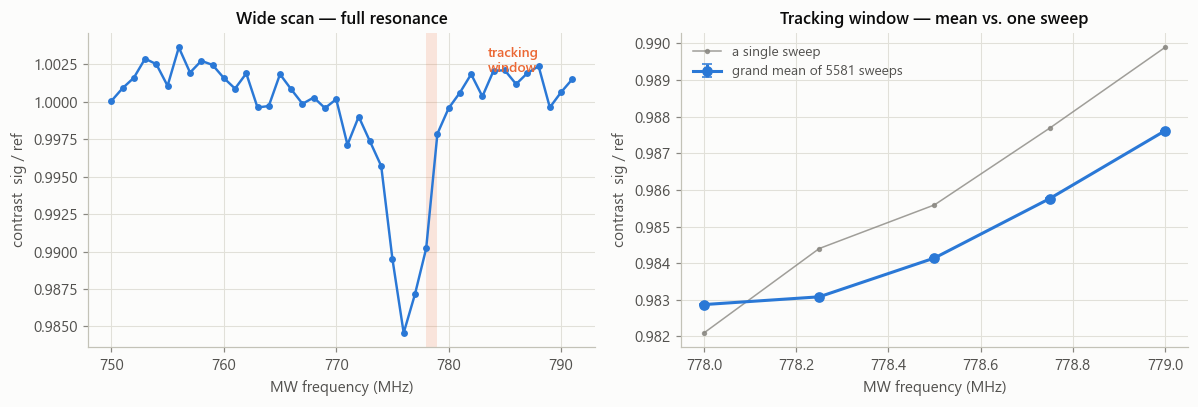

grand-mean contrast per point:
    778.00 MHz   0.982869  +/- 0.000004
    778.25 MHz   0.983081  +/- 0.000005
    778.50 MHz   0.984141  +/- 0.000006
    778.75 MHz   0.985764  +/- 0.000007
    779.00 MHz   0.987615  +/- 0.000007

single-point, single-sweep scatter (std over time): 4.31e-04


In [3]:
Cbar = c.mean(0)
Cerr = c.std(0) / np.sqrt(N)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# --- wide context scan
ax = tidy(axes[0])
if os.path.exists(WIDE_SCAN):
    W  = read_igor(WIDE_SCAN)
    wf = W[:, 0] / 1e6
    wc = W[:, SIG_COL] / W[:, REF_COL]
    ax.plot(wf, wc, color=C["blue"], marker="o", ms=3.5, lw=1.6)
    ax.axvspan(f_MHz.min(), f_MHz.max(), color=C["orange"], alpha=0.16, lw=0)
    ax.annotate("tracking\nwindow", xy=(f_MHz.mean(), ax.get_ylim()[1]),
                xytext=(f_MHz.mean() + 5, wc.max()), color=C["orange"],
                fontsize=9, ha="left", va="top", fontweight="semibold")
    ax.set_title("Wide scan — full resonance")
else:
    ax.text(0.5, 0.5, "wide scan not found", ha="center", va="center",
            transform=ax.transAxes, color=C["muted"])
ax.set_xlabel("MW frequency (MHz)")
ax.set_ylabel("contrast  sig / ref")

# --- fine window, grand mean
ax = tidy(axes[1])
ax.errorbar(f_MHz, Cbar, yerr=Cerr, color=C["blue"], marker="o", ms=6,
            capsize=3, lw=2, label=f"grand mean of {N} sweeps")
ax.plot(f_MHz, c[0], color=C["muted"], marker=".", ms=5, lw=1, alpha=0.8,
        label="a single sweep")
ax.set_xlabel("MW frequency (MHz)")
ax.set_ylabel("contrast  sig / ref")
ax.set_title("Tracking window — mean vs. one sweep")
ax.legend(fontsize=9, labelcolor=C["ink2"])

fig.tight_layout()
plt.show()

print("grand-mean contrast per point:")
for fk, ck, ek in zip(f_MHz, Cbar, Cerr):
    print(f"  {fk:8.2f} MHz   {ck:.6f}  +/- {ek:.6f}")
print(f"\nsingle-point, single-sweep scatter (std over time): {c.std(0).mean():.2e}")

## 3. Template and its derivative

The template is the empirical grand-mean curve $\bar{c}(f_k)$ — no shape model imposed. Only the
**derivative** needs smoothing, and we take it from a low-order polynomial through those five mean
points. The cell below checks that the extracted drift does not depend on that choice: degrees
2–4 give shift scatters agreeing to a few percent, so the derivative model is not driving the
result. Degree `TEMPLATE_DEG` is adopted.

derivative-model sensitivity check
 deg                    dC/df at each point (1/MHz)    shift std (MHz)
   2      [0.00048 0.00267 0.00487 0.00707 0.00926]            0.06838
   3 [-0.00130  0.00276  0.00557  0.00715  0.00749]            0.06615
   4 [-0.00118  0.00272  0.00557  0.00719  0.00737]            0.06724

adopted: degree 3
template fit residual rms : 2.66e-06   (mean-curve standard error 5.76e-06)


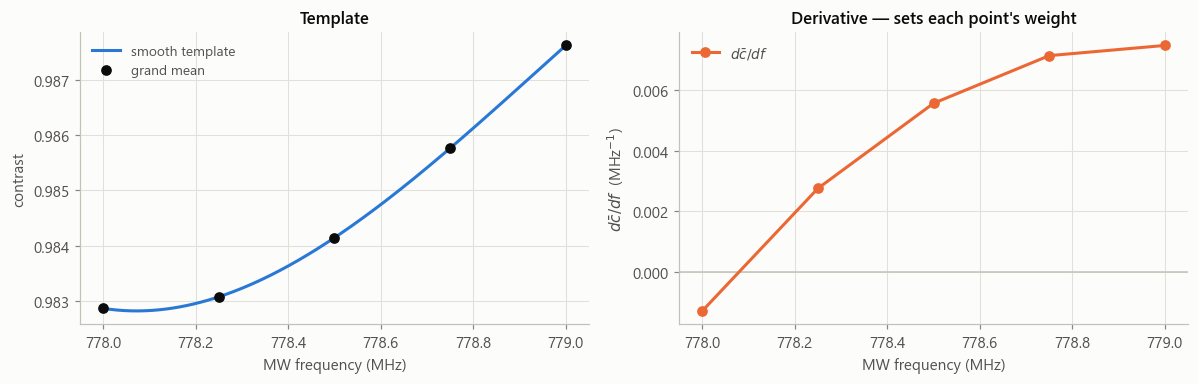

In [4]:
u = f_MHz - f_MHz.mean()          # centred frequency axis, MHz


def template_derivative(u, Cbar, deg):
    V = np.vander(u, deg + 1, increasing=True)
    q, *_ = np.linalg.lstsq(V, Cbar, rcond=None)
    dC = sum(k * q[k] * u ** (k - 1) for k in range(1, deg + 1))
    fit = V @ q
    return np.asarray(dC, float), fit, q


def fit_shift(c, Cbar, dC):
    """Per-sweep 2-parameter LSQ:  c - Cbar = A * 1 + df * (-dC).

    Returns (offset, df_MHz, residuals).
    """
    M = np.column_stack([np.ones_like(dC), -dC])
    Y = (c - Cbar).T                                  # (npts, N)
    sol, *_ = np.linalg.lstsq(M, Y, rcond=None)
    resid = Y - M @ sol
    return sol[0], sol[1], resid.T


print("derivative-model sensitivity check")
print(f"{'deg':>4} {'dC/df at each point (1/MHz)':>46}   {'shift std (MHz)':>16}")
for deg in (2, 3, 4):
    dC_, _, _ = template_derivative(u, Cbar, deg)
    _, df_, _ = fit_shift(c, Cbar, dC_)
    print(f"{deg:>4} {np.array2string(dC_, precision=5, floatmode='fixed'):>46}   {df_.std():>16.5f}")

dC, tmpl_fit, qcoef = template_derivative(u, Cbar, TEMPLATE_DEG)
print(f"\nadopted: degree {TEMPLATE_DEG}")
print(f"template fit residual rms : {np.std(Cbar - tmpl_fit):.2e}"
      f"   (mean-curve standard error {Cerr.mean():.2e})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

ax = tidy(axes[0])
fine = np.linspace(u.min(), u.max(), 200)
Vf = np.vander(fine, TEMPLATE_DEG + 1, increasing=True)
ax.plot(fine + f_MHz.mean(), Vf @ qcoef, color=C["blue"], lw=2, label="smooth template")
ax.plot(f_MHz, Cbar, "o", color=C["ink"], ms=6, label="grand mean")
ax.set_xlabel("MW frequency (MHz)"); ax.set_ylabel("contrast")
ax.set_title("Template"); ax.legend(fontsize=9, labelcolor=C["ink2"])

ax = tidy(axes[1])
ax.axhline(0, color=C["axis"], lw=1)
ax.plot(f_MHz, dC, "o-", color=C["orange"], ms=6, label=r"$d\bar{c}/df$")
ax.set_xlabel("MW frequency (MHz)"); ax.set_ylabel(r"$d\bar{c}/df$  (MHz$^{-1}$)")
ax.set_title("Derivative — sets each point's weight")
ax.legend(fontsize=9, labelcolor=C["ink2"])

fig.tight_layout(); plt.show()

## 4. Extract the per-sweep shift

Two independent estimators:

- **template** — the weighted 2-parameter fit described above, using all five points;
- **flank-3** — an ordinary straight-line fit to the three flank points only (778.5, 778.75, 779.0),
  converted to a shift through the mean flank slope.

They use different information, so agreement in their *scatter* is a meaningful check. Point-by-point
correlation between them is expected to be well below 1 at short times because both are
noise-dominated per sweep and they weight the points differently.

In [5]:
# ---- estimator 1: template shift
offset, df_MHz, resid = fit_shift(c, Cbar, dC)
df_MHz = df_MHz - df_MHz.mean()               # shift relative to the run mean

# ---- estimator 2: 3-point flank fit
flank = f_MHz >= 778.5
Xf = np.column_stack([np.ones(flank.sum()), u[flank]])
cf, *_ = np.linalg.lstsq(Xf, c[:, flank].T, rcond=None)
a3, b3 = cf
df_flank = -(a3 - a3.mean()) / b3.mean()

# ---- field conversion
def to_field_mG(df):
    return BRANCH * df / GAMMA * 1e3

dB_mG       = to_field_mG(df_MHz)
dB_mG_flank = to_field_mG(df_flank)
B0          = (D_ZFS - f_MHz.mean()) / GAMMA if BRANCH == -1 else (f_MHz.mean() - D_ZFS) / GAMMA

noise_pt = resid.std()
print(f"per-point contrast residual rms   : {noise_pt:.3e}  ({noise_pt/Cbar.mean()*1e6:.0f} ppm)")
print(f"mean flank slope                  : {b3.mean():.5f} /MHz")
print(f"operating field B0                : {B0:.1f} G   (branch f = D {'-' if BRANCH==-1 else '+'} gamma*B)")
print()
print(f"{'estimator':<12} {'std (MHz)':>10} {'p-p (MHz)':>10} {'std (mG)':>10} {'p-p (mG)':>10}")
for nm, d in (("template", df_MHz), ("flank-3", df_flank)):
    print(f"{nm:<12} {d.std():>10.4f} {np.ptp(d):>10.4f} "
          f"{abs(to_field_mG(d)).std():>10.1f} {np.ptp(to_field_mG(d)):>10.1f}")
print(f"\ncorrelation template vs flank-3 (per sweep) : {np.corrcoef(df_MHz, df_flank)[0,1]:.3f}")

# ---- validity: is the resonance still inside the window, and the flank monotonic?
span = f_MHz.max() - f_MHz.min()
out  = np.abs(df_MHz) > 0.5 * span
mono = np.all(np.diff(c[:, flank], axis=1) > 0, axis=1)
print(f"\nsweeps with |shift| > half the window ({0.5*span:.2f} MHz) : {out.sum()} / {N}")
print(f"sweeps with a non-monotonic flank                     : {(~mono).sum()} / {N}"
      f"   (expected from noise alone at this SNR)")

per-point contrast residual rms   : 2.572e-04  (261 ppm)
mean flank slope                  : 0.00695 /MHz
operating field B0                : 746.3 G   (branch f = D - gamma*B)

estimator     std (MHz)  p-p (MHz)   std (mG)   p-p (mG)
template         0.0661     0.5971       14.7      213.1
flank-3          0.0614     0.4981       13.7      177.7

correlation template vs flank-3 (per sweep) : 0.620

sweeps with |shift| > half the window (0.50 MHz) : 0 / 5581
sweeps with a non-monotonic flank                     : 7 / 5581   (expected from noise alone at this SNR)


## 5. Field vs. time

Top: the extracted field, per sweep and boxcar-smoothed, with a linear drift fit.
Bottom: the raw reference level — the laser/collection throughput — on its own axis, as a
health check. (Deliberately a separate panel, not a second y-axis on the same plot.)

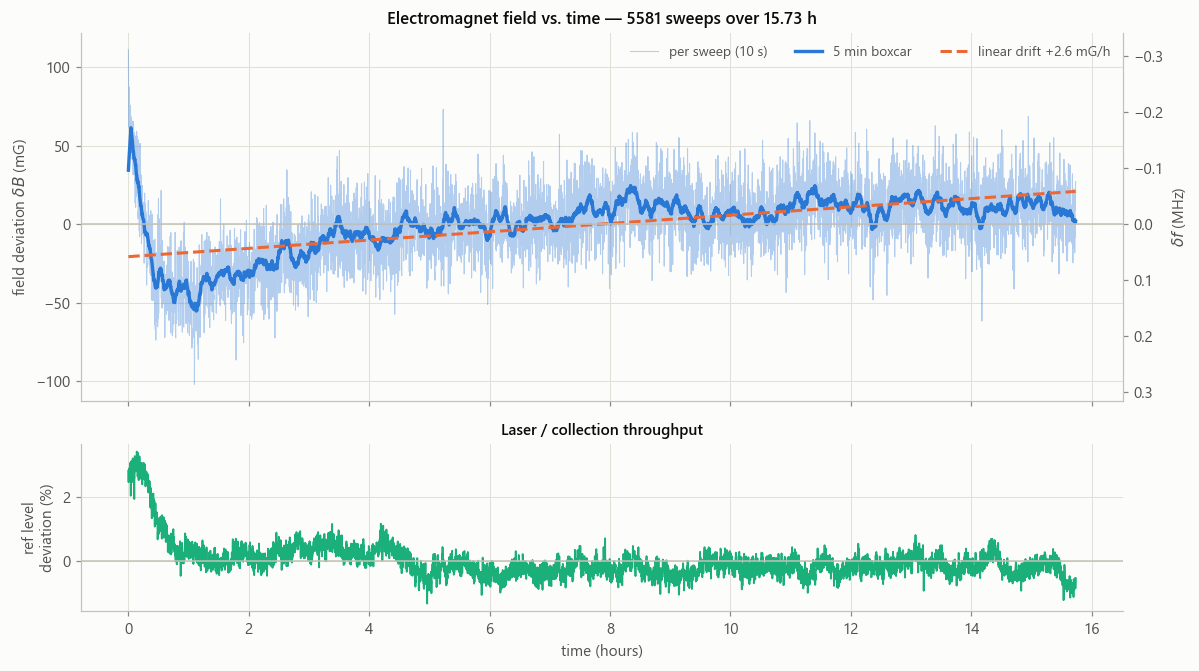

total drift over the run : +41.6 mG (-0.1165 MHz)
drift rate               : +2.64 mG/h
std about the drift line : 20.3 mG
raw std (drift included) : 23.6 mG
reference level p-p      : 4.7 %


In [6]:
lvl      = ref.mean(1)                      # mean reference counts per sweep
lvl_frac = lvl / lvl.mean()

pfit  = np.polyfit(t, dB_mG, 1)
drift = np.polyval(pfit, t)
dB_detr = dB_mG - drift

def boxcar(y, n):
    n = max(1, int(n))
    k = np.ones(n) / n
    return np.convolve(y, k, mode="same")

NSM = max(3, int(round(300 / tau0)))        # ~5 min smoothing

fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True,
                         gridspec_kw=dict(height_ratios=[2.2, 1]))

ax = tidy(axes[0])
th = t / 3600
ax.plot(th, dB_mG, color=C["blue"], lw=0.7, alpha=0.35, label="per sweep (10 s)")
ax.plot(th, boxcar(dB_mG, NSM), color=C["blue"], lw=2.2,
        label=f"{NSM*tau0/60:.0f} min boxcar")
ax.plot(th, drift, color=C["orange"], lw=2, ls="--",
        label=f"linear drift {pfit[0]*3600:+.1f} mG/h")
ax.axhline(0, color=C["axis"], lw=1)
ax.set_ylabel("field deviation $\\delta B$ (mG)")
ax.set_title(f"Electromagnet field vs. time — {N} sweeps over {t[-1]/3600:.2f} h")
ax.legend(fontsize=9, labelcolor=C["ink2"], ncol=3, loc="upper right")

sec = ax.secondary_yaxis("right", functions=(lambda b: b * 1e-3 * GAMMA * BRANCH,
                                             lambda f: f / (1e-3 * GAMMA * BRANCH)))
sec.set_ylabel("$\\delta f$ (MHz)", color=C["ink2"])
sec.tick_params(colors=C["muted"], labelcolor=C["ink2"])

ax = tidy(axes[1])
ax.plot(th, 100 * (lvl_frac - 1), color=C["aqua"], lw=1.2)
ax.axhline(0, color=C["axis"], lw=1)
ax.set_xlabel("time (hours)")
ax.set_ylabel("ref level\ndeviation (%)")
ax.set_title("Laser / collection throughput", fontsize=10)

fig.tight_layout(); plt.show()

print(f"total drift over the run : {drift[-1]-drift[0]:+.1f} mG "
      f"({(drift[-1]-drift[0])/1e3*GAMMA*BRANCH:+.4f} MHz)")
print(f"drift rate               : {pfit[0]*3600:+.2f} mG/h")
print(f"std about the drift line : {dB_detr.std():.1f} mG")
print(f"raw std (drift included) : {dB_mG.std():.1f} mG")
print(f"reference level p-p      : {np.ptp(lvl_frac)*100:.1f} %")

## 6. Allan deviation — stability vs. averaging time

The overlapping Allan deviation $\sigma_B(\tau)$ answers the operational question: *if I average
the field for $\tau$ seconds, how reproducible is that number?* A $\tau^{-1/2}$ slope is white
noise (averaging helps); a flat region is flicker; an upward turn means drift dominates and
averaging longer makes things worse. The minimum marks the best achievable stability and the
averaging time that gets you there.

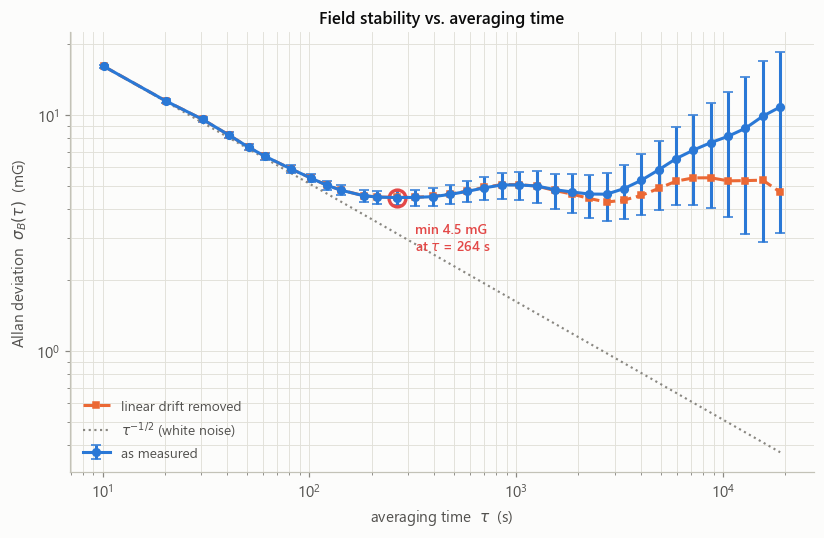

   tau (s)  sigma_f (MHz)  sigma_B (mG)
      10.2         0.0450          16.1
      40.6         0.0231           8.2
      81.3         0.0166           5.9
     142.3         0.0135           4.8
     264.2         0.0125           4.5
     477.6         0.0129           4.6
     853.6         0.0142           5.1
    1534.4         0.0135           4.8
    2733.4         0.0130           4.6
    4887.7         0.0164           5.9
    8728.7         0.0214           7.6
   15577.5         0.0277           9.9

best stability : 4.5 mG at tau = 264 s (4.4 min)


In [7]:
def overlapping_adev(y, tau0, n_tau=40):
    """Overlapping Allan deviation of a series of averaged measurements."""
    y  = np.asarray(y, float)
    n  = len(y)
    th = np.concatenate([[0.0], np.cumsum(y)]) * tau0          # phase-like integral
    ms = np.unique(np.logspace(0, np.log10(max(2, n // 3)), n_tau).astype(int))
    taus, devs, edf = [], [], []
    for m in ms:
        if 2 * m >= n:
            continue
        tau = m * tau0
        d = th[2 * m:] - 2 * th[m:-m] + th[:-2 * m]
        if d.size < 2:
            continue
        taus.append(tau)
        devs.append(np.sqrt(np.mean(d ** 2) / (2 * tau ** 2)))
        edf.append(max(1.0, n / (2 * m) - 1))                  # crude cluster count
    taus, devs, edf = map(np.array, (taus, devs, edf))
    return taus, devs, devs / np.sqrt(2 * edf)


taus, adev_f, aerr_f = overlapping_adev(df_MHz, tau0)
adev_B = np.abs(to_field_mG(adev_f))
aerr_B = np.abs(to_field_mG(aerr_f))

taus_d, adev_fd, aerr_fd = overlapping_adev(df_MHz - np.polyval(np.polyfit(t, df_MHz, 1), t), tau0)
adev_Bd = np.abs(to_field_mG(adev_fd))

imin = int(np.argmin(adev_B))

fig, ax = plt.subplots(figsize=(7.6, 5.0)); tidy(ax)
ax.errorbar(taus, adev_B, yerr=aerr_B, color=C["blue"], marker="o", ms=5,
            capsize=3, lw=2, label="as measured")
ax.plot(taus_d, adev_Bd, color=C["orange"], lw=2, ls="--", marker="s", ms=4,
        label="linear drift removed")

wn = adev_B[0] * np.sqrt(taus[0] / taus)
ax.plot(taus, wn, color=C["muted"], lw=1.4, ls=":", label=r"$\tau^{-1/2}$ (white noise)")

ax.plot(taus[imin], adev_B[imin], "o", ms=11, mfc="none", mec=C["red"], mew=2.2)
ax.annotate(f"min {adev_B[imin]:.1f} mG\nat $\\tau$ = {taus[imin]:.0f} s",
            xy=(taus[imin], adev_B[imin]), xytext=(12, -34),
            textcoords="offset points", color=C["red"], fontsize=9,
            fontweight="semibold")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"averaging time  $\tau$  (s)")
ax.set_ylabel(r"Allan deviation  $\sigma_B(\tau)$  (mG)")
ax.set_title("Field stability vs. averaging time")
ax.grid(True, which="both", color=C["grid"], lw=0.6)
ax.legend(fontsize=9, labelcolor=C["ink2"])
fig.tight_layout(); plt.show()

print(f"{'tau (s)':>10} {'sigma_f (MHz)':>14} {'sigma_B (mG)':>13}")
for i in range(0, len(taus), max(1, len(taus)//10)):
    print(f"{taus[i]:>10.1f} {adev_f[i]:>14.4f} {adev_B[i]:>13.1f}")
print(f"\nbest stability : {adev_B[imin]:.1f} mG at tau = {taus[imin]:.0f} s "
      f"({taus[imin]/60:.1f} min)")

## 7. Noise spectrum and single-sweep distribution

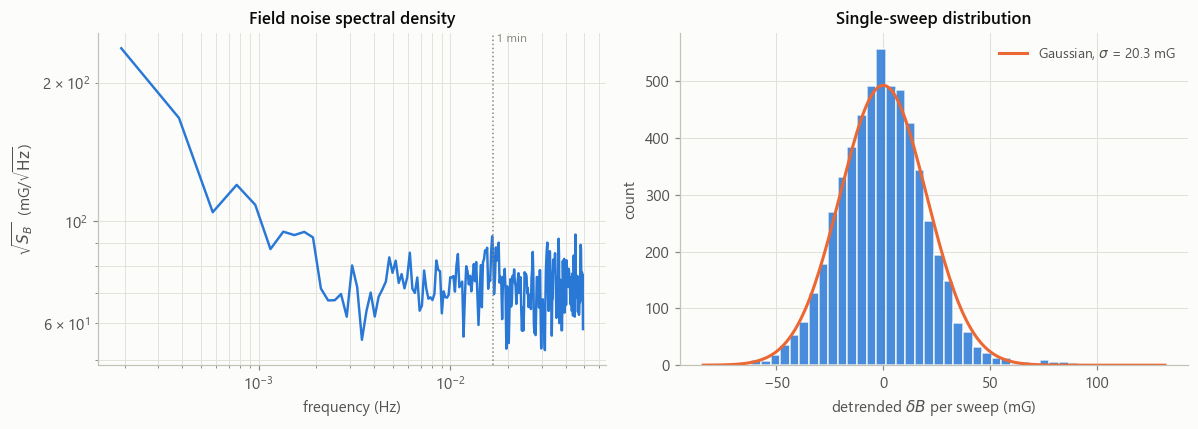

single-sweep (10 s) white-noise floor : 16.1 mG
implied sensitivity                      : 51 mG/sqrt(Hz)  =  0.144 MHz/sqrt(Hz)
detrended per-sweep std                  : 20.3 mG


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

# --- PSD
ax = tidy(axes[0])
fs = 1.0 / tau0
nper = min(512, len(dB_detr) // 4 * 2)
fr, P = sps.welch(dB_detr, fs=fs, nperseg=nper, detrend="linear")
m = fr > 0
ax.loglog(fr[m], np.sqrt(P[m]), color=C["blue"], lw=1.6)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel(r"$\sqrt{S_B}$  (mG/$\sqrt{\mathrm{Hz}}$)")
ax.set_title("Field noise spectral density")
ax.grid(True, which="both", color=C["grid"], lw=0.6)
ax.axvline(1/60,   color=C["muted"], lw=1, ls=":")
ax.text(1/60, ax.get_ylim()[1], " 1 min", color=C["muted"], fontsize=8, va="top")

# --- histogram
ax = tidy(axes[1])
ax.hist(dB_detr, bins=48, color=C["blue"], alpha=0.85, edgecolor=C["surface"], lw=0.6)
s = dB_detr.std()
xs = np.linspace(dB_detr.min(), dB_detr.max(), 200)
ax.plot(xs, len(dB_detr)*(dB_detr.max()-dB_detr.min())/48
        * np.exp(-xs**2/(2*s**2))/(s*np.sqrt(2*np.pi)),
        color=C["orange"], lw=2, label=f"Gaussian, $\\sigma$ = {s:.1f} mG")
ax.set_xlabel("detrended $\\delta B$ per sweep (mG)")
ax.set_ylabel("count")
ax.set_title("Single-sweep distribution")
ax.legend(fontsize=9, labelcolor=C["ink2"])

fig.tight_layout(); plt.show()

eta_B = adev_B[0] * np.sqrt(taus[0])
print(f"single-sweep ({tau0:.0f} s) white-noise floor : {adev_B[0]:.1f} mG")
print(f"implied sensitivity                      : {eta_B:.0f} mG/sqrt(Hz)"
      f"  =  {eta_B/1e3*GAMMA:.3f} MHz/sqrt(Hz)")
print(f"detrended per-sweep std                  : {s:.1f} mG")

## 8. Systematics — is the slow drift really the magnet?

The extracted resonance shift and the laser/collection level both wander on hour timescales, so a
raw correlation between them is not evidence of coupling. The discriminating test is the
**first-difference correlation**, which removes all slow common behaviour and asks whether the two
move together *sweep to sweep*.

- A near-zero first-difference correlation means there is **no fast coupling** — the short-$\tau$
  Allan deviation is genuine field/readout noise.
- A large detrended correlation with near-zero first-difference correlation means the two merely
  co-drift. This dataset **cannot** separate a true slow field drift from a slow readout systematic
  (e.g. a thermal effect moving both). Treat the long-$\tau$ Allan floor as an *upper bound* on the
  magnet's own instability.

To settle it, you would need an independent handle — e.g. interleaving both hyperfine/branch
transitions, since a real field shift moves them oppositely while a readout systematic moves them
together.

corr(ref level, shift)  raw                : +0.109
                        linearly detrended : -0.181
                        first differences  : -0.033   <-- fast coupling
corr(ref level, fitted common-mode offset) : -0.168

=> No fast coupling. Short-tau noise is not laser-level crosstalk.
=> No appreciable slow co-drift; the drift term is plausibly the magnet.


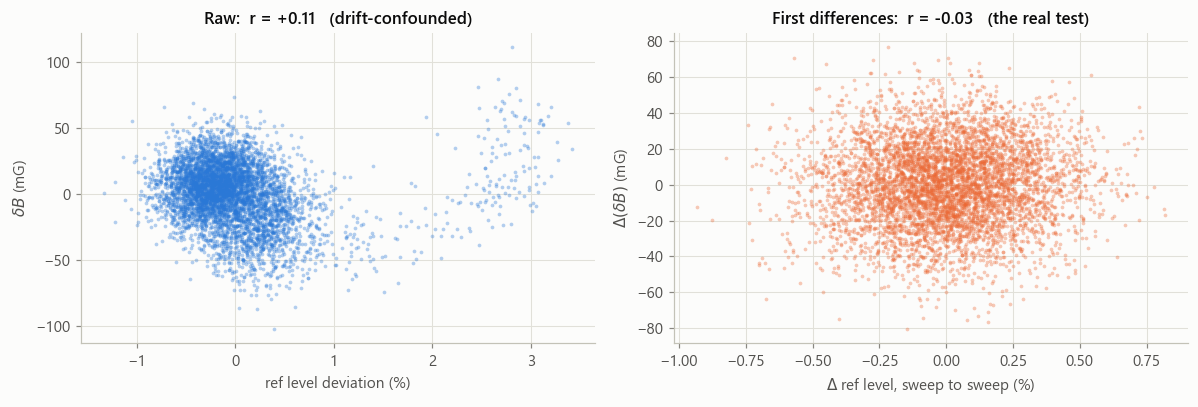

In [9]:
def detrend_lin(y):
    return y - np.polyval(np.polyfit(t, y, 1), t)

r_raw  = np.corrcoef(lvl, df_MHz)[0, 1]
r_detr = np.corrcoef(detrend_lin(lvl), detrend_lin(df_MHz))[0, 1]
r_diff = np.corrcoef(np.diff(lvl), np.diff(df_MHz))[0, 1]
r_off  = np.corrcoef(lvl, offset)[0, 1]

print(f"corr(ref level, shift)  raw                : {r_raw:+.3f}")
print(f"                        linearly detrended : {r_detr:+.3f}")
print(f"                        first differences  : {r_diff:+.3f}   <-- fast coupling")
print(f"corr(ref level, fitted common-mode offset) : {r_off:+.3f}")
print()
if abs(r_diff) < 0.1:
    print("=> No fast coupling. Short-tau noise is not laser-level crosstalk.")
else:
    print("=> Fast coupling present; the short-tau floor is partly a readout artefact.")
if abs(r_detr) > 0.3:
    print("=> Slow co-drift IS present: the long-tau floor is an UPPER BOUND on magnet drift.")
else:
    print("=> No appreciable slow co-drift; the drift term is plausibly the magnet.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = tidy(axes[0])
ax.scatter(100*(lvl_frac-1), dB_mG, s=6, color=C["blue"], alpha=0.35, lw=0)
ax.set_xlabel("ref level deviation (%)"); ax.set_ylabel("$\\delta B$ (mG)")
ax.set_title(f"Raw:  r = {r_raw:+.2f}   (drift-confounded)")

ax = tidy(axes[1])
ax.scatter(100*np.diff(lvl)/lvl.mean(), to_field_mG(np.diff(df_MHz)),
           s=6, color=C["orange"], alpha=0.35, lw=0)
ax.set_xlabel("$\\Delta$ ref level, sweep to sweep (%)")
ax.set_ylabel("$\\Delta(\\delta B)$ (mG)")
ax.set_title(f"First differences:  r = {r_diff:+.2f}   (the real test)")

fig.tight_layout(); plt.show()

## 9. Summary

In [10]:
rows = [
    ("run",                        f"{SERIES}_*"),
    ("sweeps",                     f"{N}"),
    ("duration",                   f"{t[-1]/3600:.2f} h"),
    ("sweep period",               f"{tau0:.1f} s"),
    ("window",                     f"{f_MHz.min():.2f} - {f_MHz.max():.2f} MHz, {len(f_MHz)} pts"),
    ("operating field",            f"{B0:.1f} G"),
    ("", ""),
    ("single-sweep noise (10 s)",  f"{adev_B[0]:.1f} mG      ({adev_f[0]*1e3:.0f} kHz)"),
    ("sensitivity",                f"{eta_B:.0f} mG/sqrt(Hz)"),
    ("best stability",             f"{adev_B[imin]:.1f} mG at tau = {taus[imin]:.0f} s"),
    ("linear drift",               f"{pfit[0]*3600:+.1f} mG/h"),
    ("total excursion (run)",      f"{np.ptp(boxcar(dB_mG, NSM)[NSM:-NSM]):.0f} mG smoothed"),
    ("", ""),
    ("fractional stability",       f"{adev_B[imin]/1e3/B0:.2e}  at best tau"),
    ("fractional drift",           f"{abs(pfit[0])*3600/1e3/B0:.2e} /h"),
]
w = max(len(a) for a, _ in rows)
print("=" * (w + 34))
for a, b in rows:
    print(f"{a:<{w}}  {b}" if a else "")
print("=" * (w + 34))

run                        ODMR_2026-8-4_Ave_026_*
sweeps                     5581
duration                   15.73 h
sweep period               10.2 s
window                     778.00 - 779.00 MHz, 5 pts
operating field            746.3 G

single-sweep noise (10 s)  16.1 mG      (45 kHz)
sensitivity                51 mG/sqrt(Hz)
best stability             4.5 mG at tau = 264 s
linear drift               +2.6 mG/h
total excursion (run)      101 mG smoothed

fractional stability       5.99e-06  at best tau
fractional drift           3.54e-06 /h


### How to read this

- **Short term** the field is stable at the tens-of-mG level per 10 s sweep; this is set by
  photon shot noise on the flank, not by the magnet.
- **Averaging helps** down to the Allan minimum. Past that, drift takes over — averaging a field
  measurement for longer than that time buys nothing.
- **The drift rate** is the number to quote for the magnet, with the caveat from §8 that it is an
  upper bound while readout drift is not independently excluded.

### Reusing this on another run

Change `SERIES` (and `DATA_DIR` / `WIDE_SCAN`) in the config cell and re-run. Everything
downstream is driven by the loaded array. If a future run is taken on the **upper** ODMR branch,
set `BRANCH = +1`. If the sweep window is repositioned so that all points sit on a straight
flank, the template estimator still works unchanged — it simply reduces to a slope inversion.